# Time Series Visualisation – Bike Sharing Demand
Aggregates hourly rental data to **weekly** totals for London, Seoul, and Washington.  
Output saved to `results/figures/` (no figure titles — ready for presentation and paper submission).

In [1]:
import os

# ── Root anchoring ─────────────────────────────────────────────────────────────
# All paths in this notebook are relative to the project root.
# Since the notebook lives in analysis_visualizations/, step up one level.
os.chdir(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))
print('Working directory:', os.getcwd())

Working directory: /Users/mayte/GitHub/TabPFN-TS_for_Bike_Demand_Forecasting


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path

# ── Output directory ───────────────────────────────────────────────────────────
FIGURES_DIR = Path('results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
# ── Helper ─────────────────────────────────────────────────────────────────────
def load_and_aggregate(path, ts_col, cnt_col, freq='W'):
    df = pd.read_csv(path, parse_dates=[ts_col])
    df = df[df['Functioning Day'].str.strip() == 'Yes']
    series = df.set_index(ts_col)[cnt_col].resample(freq).sum()
    series = series.iloc[1:-1]   # drop first & last partial week
    return series

In [4]:
def load_daily(path, ts_col, cnt_col):
    df = pd.read_csv(path, parse_dates=[ts_col])
    df = df[df['Functioning Day'].str.strip() == 'Yes']
    s = df.set_index(ts_col)[cnt_col].resample('D').sum()
    return s.iloc[1:-1]

In [5]:
# ── Load datasets ──────────────────────────────────────────────────────────────
london = load_and_aggregate(
    'data/LondonBikeData.csv',
    ts_col='timestamp',
    cnt_col='cnt'
)

seoul = load_and_aggregate(
    'data/SeoulBikeData.csv',
    ts_col='Date',
    cnt_col='Rented Bike Count'
)

washington = load_and_aggregate(
    'data/WashingtonBikeData.csv',
    ts_col='timestamp',
    cnt_col='cnt'
)

# Quick summary
for name, s in [('London', london), ('Seoul', seoul), ('Washington', washington)]:
    print(f"{name:12s}  {s.index[0].date()} → {s.index[-1].date()}  "
          f"({len(s)} weeks)  max weekly: {s.max():,.0f}")

London        2015-01-11 → 2017-01-01  (104 weeks)  max weekly: 298,845
Seoul         2017-12-10 → 2018-11-25  (51 weeks)  max weekly: 225,206
Washington    2011-01-09 → 2012-12-30  (104 weeks)  max weekly: 55,022


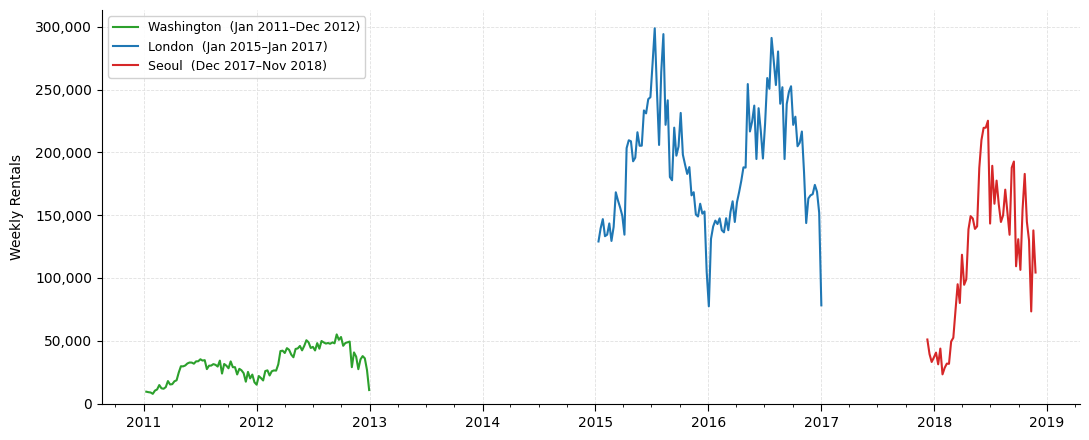

In [6]:
# ── Plot ───────────────────────────────────────────────────────────────────────
COLORS = {
    'London':     '#1f77b4',   # steel blue
    'Seoul':      '#d62728',   # brick red
    'Washington': '#2ca02c',   # forest green
}

plt.rcParams.update({
    'font.family':       'sans-serif',   # clean, no fallback surprises
    'font.sans-serif':   ['DejaVu Sans'],
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e0e0e0',
    'grid.linewidth':    0.6,
    'grid.linestyle':    '--',
})

fig, ax = plt.subplots(figsize=(11, 4.5))

datasets = {
    'Washington': washington,
    'London':     london,
    'Seoul':      seoul,
}

for city, series in datasets.items():
    color = COLORS[city]
    label = (
        f"{city}  "
        f"({series.index[0].strftime('%b %Y')}–"
        f"{series.index[-1].strftime('%b %Y')})"
    )
    ax.plot(series.index, series.values,
            color=color, linewidth=1.5, label=label)

# ── X-axis: one tick per year, just the 4-digit year ──────────────────────────
# Works cleanly regardless of how many years the combined data spans.
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))  # subtle Q guides
ax.tick_params(axis='x', which='major', length=5, pad=4)
ax.tick_params(axis='x', which='minor', length=2)

# ── Y-axis ─────────────────────────────────────────────────────────────────────
ax.set_xlabel('', labelpad=8)
ax.set_ylabel('Weekly Rentals', labelpad=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_ylim(bottom=0)

# ── Legend ─────────────────────────────────────────────────────────────────────
ax.legend(
    frameon=True, framealpha=0.9, edgecolor='#cccccc',
    loc='upper left', fontsize=9
)

fig.tight_layout()

# ── Save ───────────────────────────────────────────────────────────────────────

fig.savefig(FIGURES_DIR / 'timeseries_weekly_rentals.png', dpi=150, bbox_inches='tight')
plt.show()

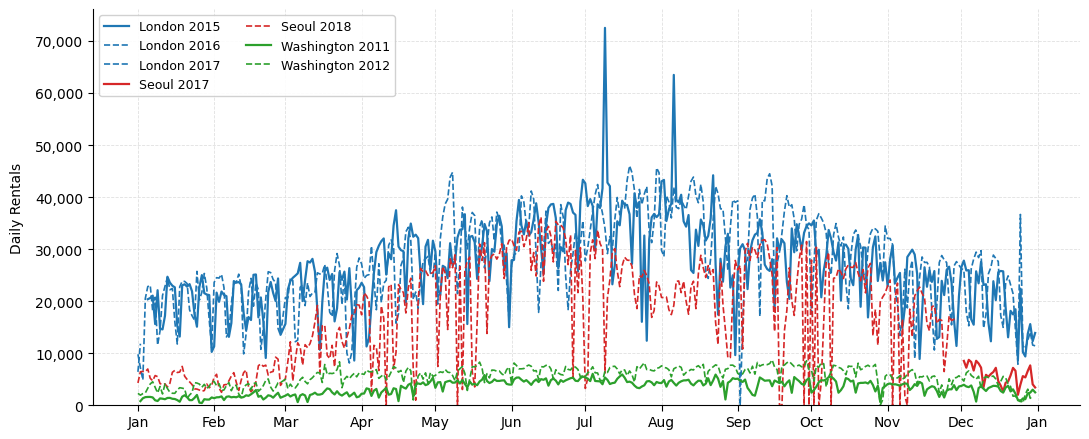

In [9]:
# ── Seasonal overlay: all cities, split by calendar year ──────────────────────
# X-axis = day-of-year → all years align so seasonality is directly comparable.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path

FIGURES_DIR = Path('results/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

COLORS = {
    'London':     '#1f77b4',
    'Seoul':      '#d62728',
    'Washington': '#2ca02c',
}

plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['DejaVu Sans'],
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#e0e0e0',
    'grid.linewidth':    0.6,
    'grid.linestyle':    '--',
})

# ── Re-use daily aggregation (smoother than weekly for seasonal shape) ─────────


london     = load_daily('data/LondonBikeData.csv',     'timestamp', 'cnt')
seoul      = load_daily('data/SeoulBikeData.csv',      'Date',      'Rented Bike Count')
washington = load_daily('data/WashingtonBikeData.csv', 'timestamp', 'cnt')

datasets = {'London': london, 'Seoul': seoul, 'Washington': washington}

# ── Build a "day-of-year" axis using a fixed leap year as reference (2000) ─────
# This gives a proper date x-axis (Jan–Dec) for all series.
def to_doy_series(series):
    """Return dict of {year: Series indexed by 2000-MM-DD}."""
    out = {}
    for yr, grp in series.groupby(series.index.year):
        # map each date to the same year (2000) keeping month+day
        idx = grp.index.map(
            lambda d: d.replace(year=2000) if not (d.month == 2 and d.day == 29)
                      else pd.NaT
        )
        s = pd.Series(grp.values, index=idx).dropna()
        s = s[~s.index.duplicated()]          # safety: drop any Feb-29 duplicates
        out[yr] = s.sort_index()
    return out

fig, ax = plt.subplots(figsize=(11, 4.5))

for city, series in datasets.items():
    color   = COLORS[city]
    by_year = to_doy_series(series)
    years   = sorted(by_year.keys())

    for i, yr in enumerate(years):
        ls    = '-' if i == 0 else '--'        # solid = 1st year, dashed = 2nd
        lw    = 1.6 if i == 0 else 1.2
        label = f'{city} {yr}' if len(years) > 1 else city
        ax.plot(by_year[yr].index, by_year[yr].values,
                color=color, linestyle=ls, linewidth=lw, label=label)

# ── X-axis: month names ────────────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.tick_params(axis='x', which='major', length=4, pad=3)

ax.set_xlabel('', labelpad=8)
ax.set_ylabel('Daily Rentals', labelpad=8)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.legend(frameon=True, framealpha=0.9, edgecolor='#cccccc',
          loc='upper left', fontsize=9, ncol=2)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'timeseries_seasonal_overlay.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'timeseries_seasonal_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

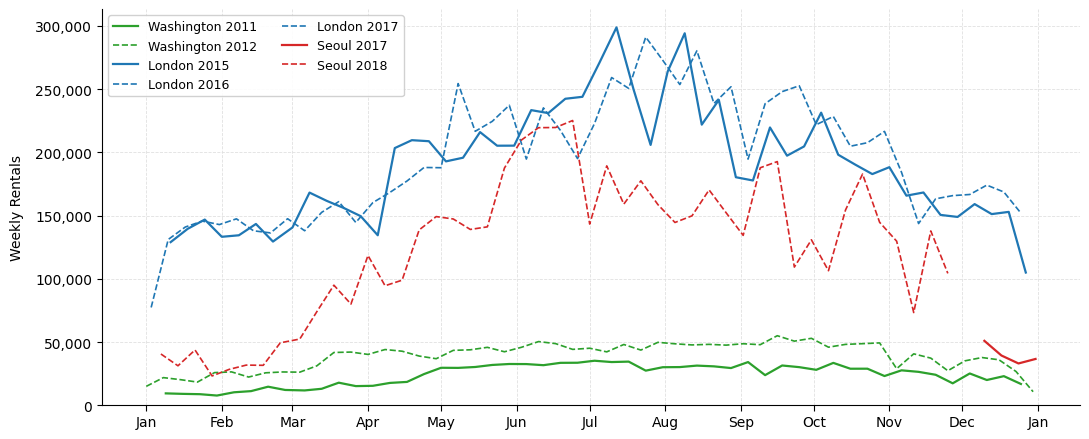

In [10]:
# ── Weekly version of the seasonal overlay ────────────────────────────────────

def load_weekly(path, ts_col, cnt_col):
    df = pd.read_csv(path, parse_dates=[ts_col])
    df = df[df['Functioning Day'].str.strip() == 'Yes']
    s = df.set_index(ts_col)[cnt_col].resample('W').sum()
    return s.iloc[1:-1]

london_w     = load_weekly('data/LondonBikeData.csv',     'timestamp', 'cnt')
seoul_w      = load_weekly('data/SeoulBikeData.csv',      'Date',      'Rented Bike Count')
washington_w = load_weekly('data/WashingtonBikeData.csv', 'timestamp', 'cnt')

datasets_w = {'Washington': washington_w, 'London': london_w, 'Seoul': seoul_w, 'Washington': washington_w}

fig, ax = plt.subplots(figsize=(11, 4.5))

for city, series in datasets_w.items():
    color   = COLORS[city]
    by_year = to_doy_series(series)   # reuse the same helper as before
    years   = sorted(by_year.keys())

    for i, yr in enumerate(years):
        ls    = '-' if i == 0 else '--'
        lw    = 1.6 if i == 0 else 1.2
        label = f'{city} {yr}' if len(years) > 1 else city
        ax.plot(by_year[yr].index, by_year[yr].values,
                color=color, linestyle=ls, linewidth=lw, label=label)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.tick_params(axis='x', which='major', length=4, pad=3)

ax.set_xlabel('', labelpad=8)
ax.set_ylabel('Weekly Rentals', labelpad=8)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.legend(frameon=True, framealpha=0.9, edgecolor='#cccccc',
          loc='upper left', fontsize=9, ncol=2)

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'timeseries_seasonal_overlay_weekly.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_DIR / 'timeseries_seasonal_overlay_weekly.png', dpi=150, bbox_inches='tight')
plt.show()